 최적의 하이퍼파라미터 조합: {'C': 0.1, 'class_weight': {0: 1, 1: 5}, 'solver': 'liblinear'}


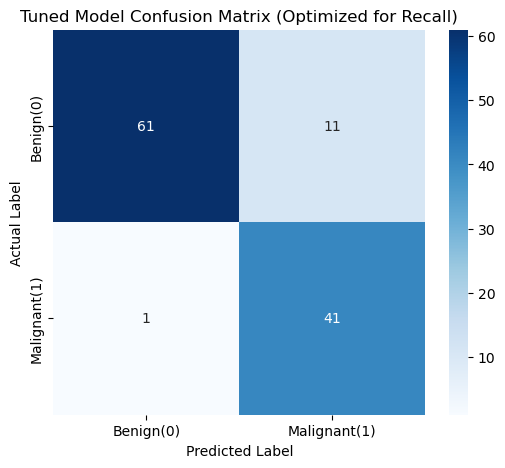


---  Tuned Clinical Classification Report ---
              precision    recall  f1-score   support

   Benign(0)       0.98      0.85      0.91        72
Malignant(1)       0.79      0.98      0.87        42

    accuracy                           0.89       114
   macro avg       0.89      0.91      0.89       114
weighted avg       0.91      0.89      0.90       114



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# 이전 단계의 데이터 및 변수 세팅 (재현)
cancer_data = load_breast_cancer()
df = pd.DataFrame(data=cancer_data.data, columns=cancer_data.feature_names)
y = np.where(cancer_data.target == 0, 1, 0)
X = df[['mean area', 'mean concavity', 'mean symmetry']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  하이퍼파라미터 및 방어 논리(Class Weight) 탐색망 구축
# - C: 규제 강도의 역수 (작을수록 강력한 규제)
# - penalty: 가중치 압축 방식
# - class_weight: 악성(1) 데이터에 부여할 수학적 가중치
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear'],
    'class_weight': ['balanced', {0: 1, 1: 3}, {0: 1, 1: 5}]
}

# . GridSearchCV 실행 (Data Leakage 차단 및 Recall 최적화)
grid_search = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,               # 학습 데이터를 다시 5개로 쪼개어 교차 검증
    scoring='recall',   # 임상적 목표인 '재현율 극대화'로 탐색 지표 고정
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print(f" 최적의 하이퍼파라미터 조합: {grid_search.best_params_}")

# 4. 고립된 Test Set에 단 한 번의 최종 평가 수행
y_pred_tuned = best_model.predict(X_test_scaled)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign(0)', 'Malignant(1)'], 
            yticklabels=['Benign(0)', 'Malignant(1)'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Tuned Model Confusion Matrix (Optimized for Recall)')
plt.savefig('../images/tuned_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n---  Tuned Clinical Classification Report ---")
print(classification_report(y_test, y_pred_tuned, target_names=['Benign(0)', 'Malignant(1)']))